In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



pd.set_option('display.max_columns', None)


### DATA INGESTION

In [3]:
df=pd.read_csv(r'Dataset/train.csv')


C:\Users\abc\AppData\Local\Temp\ipykernel_21556\1547163279.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'Dataset/train.csv')


In [4]:
df.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


#### The Daily Sales dataset is used to analyze daily sales performance and customer behavior across stores.
#### It provides historical data required for forecasting future sales and generating business KPIs.
#### It helps identify patterns such as peak sales days, promotion impact, and customer traffic trends

In [43]:
store_data=pd.read_csv(r'Dataset/store.csv')

In [6]:
store_data.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### The store dataset is used to understand store characteristics that influence sales performance.
#### It helps analyze how factors like store type, assortment, and nearby competition affect revenue.
#### It provides additional context required for accurate sales prediction and business insights.

#### The Daily Sales and Store datasets are merged to combine daily sales data with store-level attributes for comprehensive analysis.
#### This integration enables better forecasting, performance comparison, and KPI generation.

# Exploratory Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [8]:
df.describe(include="all")

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1017209,1.017209e+06
unique,NaN,NaN,942,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,2015-07-31,NaN,NaN,NaN,NaN,0,NaN
freq,NaN,NaN,1115,NaN,NaN,NaN,NaN,855087,NaN
mean,5.584297e+02,3.998341e+00,NaN,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,NaN,1.786467e-01
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,NaN,3.830564e-01
min,1.000000e+00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00
25%,2.800000e+02,2.000000e+00,NaN,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00
50%,5.580000e+02,4.000000e+00,NaN,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00
75%,8.380000e+02,6.000000e+00,NaN,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,NaN,0.000000e+00


### DATASET OVERVIEW
#### Daily Sales Dataset has 1M+ records,Sales vary significantly,Some stores are closed (sales = 0),Promotions occur 38% of time.
#### School holidays occur 18% of time, Most days are not holidays, Customer count strongly drives sales , Dataset covers full weekly operations, Wide distribution of stores results in good diversity in data.

In [9]:
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

#### No missing values and duplicates were detected in the Daily Sales dataset across all features, indicating high data completeness and reducing the need for data imputation during preprocessing.

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

print(min(df['Date']))
print(max(df['Date']))

2013-01-01 00:00:00
2015-07-31 00:00:00


#### Daily Sales for each store is recorded for 2 years and 7 months.

In [12]:
for col in df.columns:
    print(col, df[col].nunique())

Store 1115
DayOfWeek 7
Date 942
Sales 21734
Customers 4086
Open 2
Promo 2
StateHoliday 5
SchoolHoliday 2


In [13]:
print(df['StateHoliday'].unique())

df['StateHoliday'] = df['StateHoliday'].replace({'a':1, 1: '1'})


['0' 'a' 'b' 'c' 0]


#### I determined that certain variables were categorical by analyzing their meaning and the number of unique values. Although they were stored as numbers, they represented labels or states rather than measurable quantities, so I treated them as categorical features.

categorical_cols = [
    "StateHoliday",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

df.dtypes

#### They are not continuous numeric measurements — they represent labels, flags, or groups.
#### StateHoliday → Categorical 0 → No holiday
#### a → Public holiday
#### b → Easter holiday
#### c → Christmas
#### DayOfWeek: These represent days (Monday–Sunday), not quantities.
#### Open: This is a binary indicator (0 or 1) of whether the store is open, not a numeric measurement.
#### Promo: This is a binary indicator (0 or 1) of whether a promotion is active, not a numeric measurement.
#### SchoolHoliday: This is a binary indicator (0 or 1) of whether it is a school holiday, not a numeric measurement.


#### These are labels not numeric values, so they are better represented as categorical data types. This allows for more efficient storage and appropriate handling in analyses and modeling.

# DATA VISUALIZATION

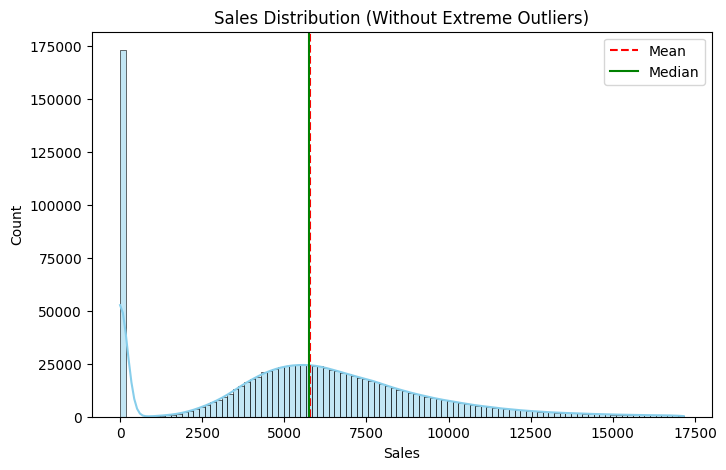

In [15]:
plt.figure(figsize=(8,5))

# Limit range to 99th percentile
upper_limit = df["Sales"].quantile(0.99)

sns.histplot(
    df[df["Sales"] <= upper_limit]["Sales"],
    bins=100,
    kde=True,
    color="skyblue"
)

plt.axvline(df["Sales"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["Sales"].median(), color="green", linestyle="-", label="Median")

plt.title("Sales Distribution (Without Extreme Outliers)")
plt.legend()
plt.show()

### Sales distribution is right-skewed, indicating occasional high sales spikes.

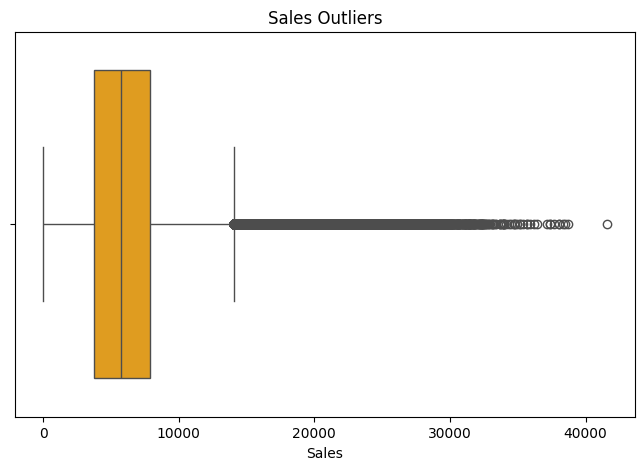

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"],
    color="orange"
)

plt.title("Sales Outliers")
plt.show()

### Sales contain outliers representing peak demand periods or high-performing stores.

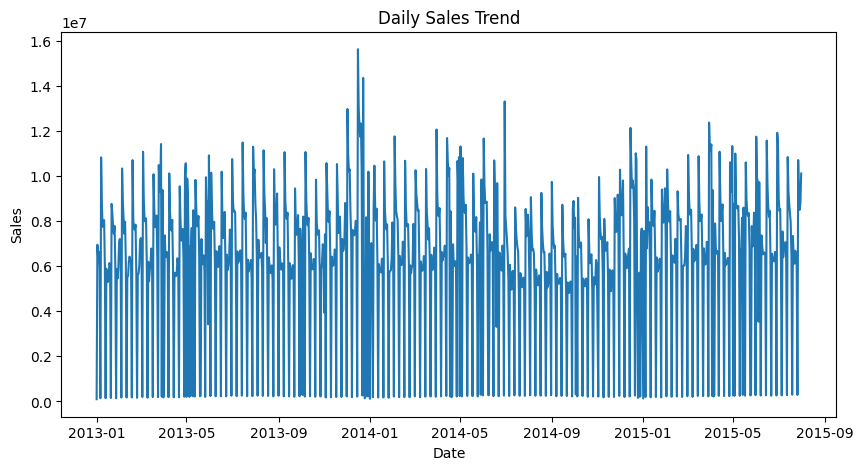

In [17]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(10,5))

sns.lineplot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Sales exhibit time-based patterns suitable for forecasting analysis.

C:\Users\abc\AppData\Local\Temp\ipykernel_18188\245676813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


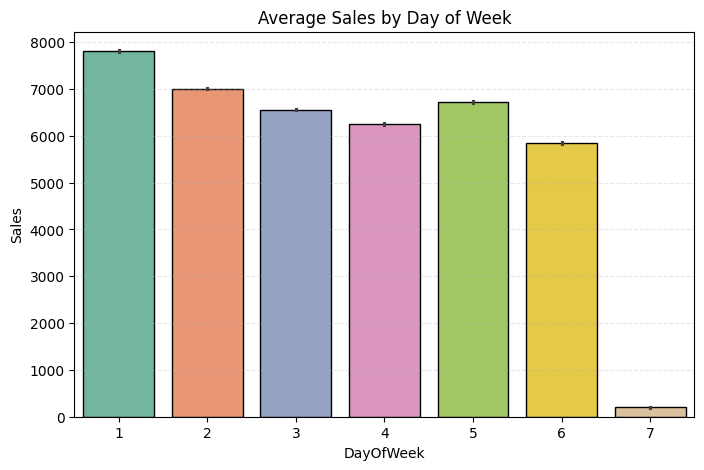

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="DayOfWeek",
    y="Sales",
    data=df,
    palette="Set2",
    edgecolor="black"
)

plt.title("Average Sales by Day of Week")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show
plt.show()

In [19]:
df.groupby("DayOfWeek")["Open"].apply(lambda x: x.astype(int).mean())

DayOfWeek
1    0.950459
2    0.988309
3    0.974400
4    0.923199
5    0.950598
6    0.995357
7    0.024826
Name: Open, dtype: float64

### Stores are open on more than 92–99% of weekdays and Saturdays, but only about 2% of stores operate on Sundays, which explains the significantly lower sales observed on that day.

C:\Users\abc\AppData\Local\Temp\ipykernel_18188\3947741051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


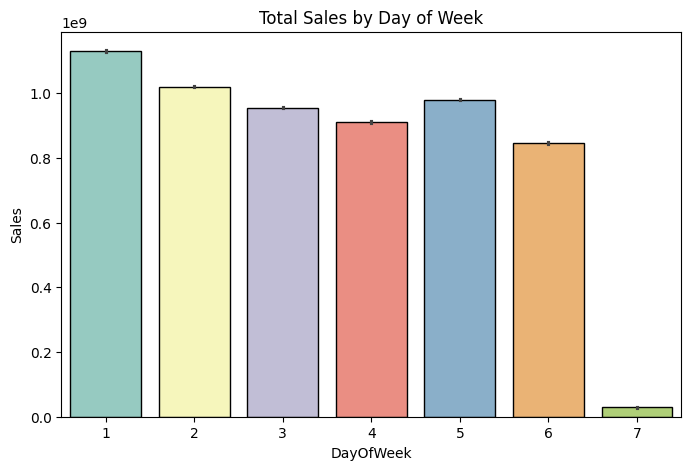

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="DayOfWeek",
    y="Sales",
    data=df,
    estimator=sum,
    palette="Set3",
    edgecolor="black"
)

plt.title("Total Sales by Day of Week")

plt.show()

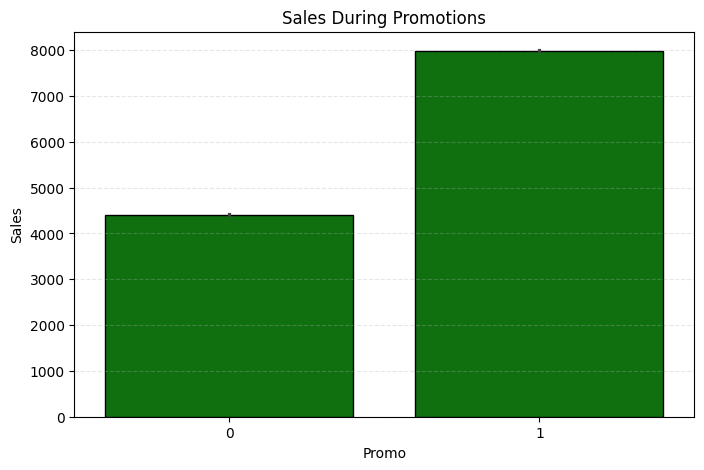

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Promo",
    y="Sales",
    data=df,
    color='green',
    edgecolor='black'
    
)

plt.title("Sales During Promotions")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


### Promotions significantly increase sales performance.

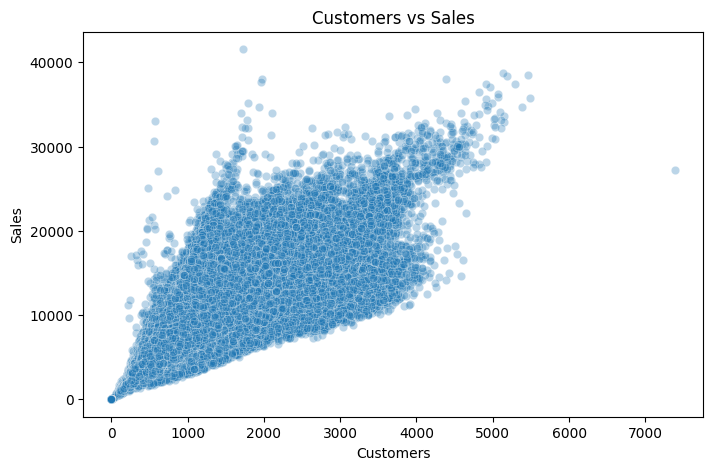

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Customers",
    y="Sales",
    data=df,
    alpha=0.3
)

plt.title("Customers vs Sales")
plt.show()

### Sales increase as customer numbers rise, indicating a strong positive relationship

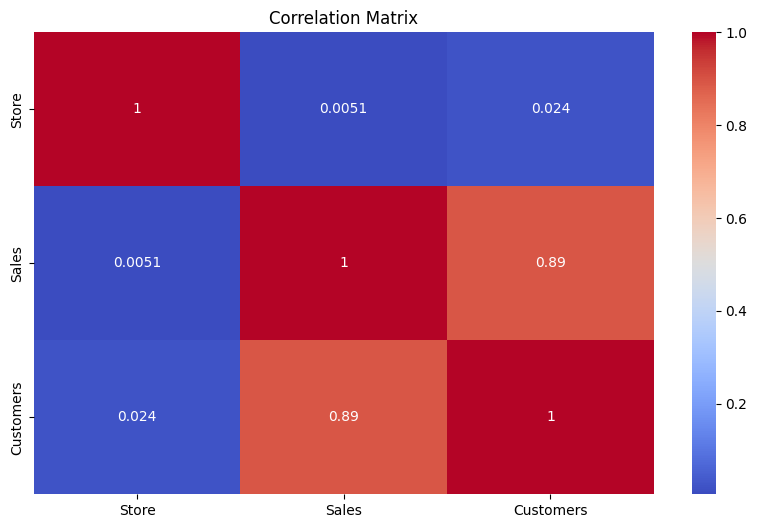

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Customers show the strongest correlation with sales among numerical features.

C:\Users\abc\AppData\Local\Temp\ipykernel_18188\3752296556.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


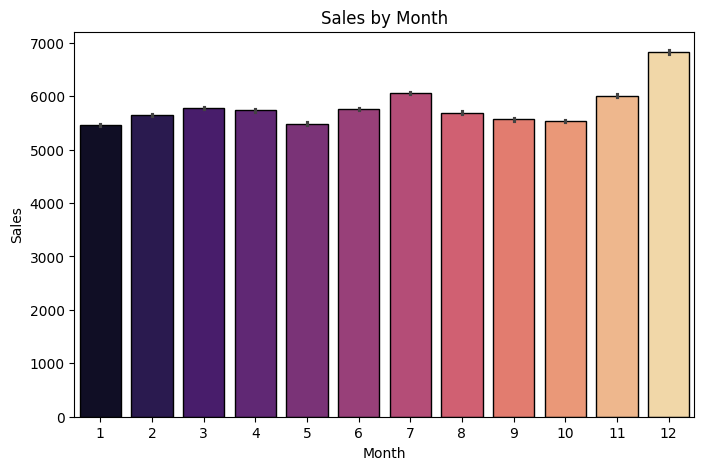

In [24]:
df["Month"] = df["Date"].dt.month

plt.figure(figsize=(8,5))

sns.barplot(
    x="Month",
    y="Sales",
    data=df,
    palette="magma",
    edgecolor="black"

)

plt.title("Sales by Month")
plt.show()

### Sales vary across months, indicating seasonal demand patterns.

In [8]:
df = df[df["Open"] == 1]

In [9]:
store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [27]:
store_data.describe(include="all")

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
count,1115.00000,1115,1115,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000,571
unique,NaN,4,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,a,a,NaN,NaN,NaN,NaN,NaN,NaN,"Jan,Apr,Jul,Oct"
freq,NaN,602,593,NaN,NaN,NaN,NaN,NaN,NaN,335
mean,558.00000,NaN,NaN,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573,NaN
std,322.01708,NaN,NaN,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935,NaN
min,1.00000,NaN,NaN,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000,NaN
25%,279.50000,NaN,NaN,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000,NaN
50%,558.00000,NaN,NaN,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000,NaN
75%,836.50000,NaN,NaN,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000,NaN


#### The store dataset reveals a highly diverse retail network with varying store types, competition distances, and promotional strategies. These factors significantly influence sales behavior and are crucial for improving forecasting accuracy.

In [28]:
store_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [29]:
store_data.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

#### Competitor timing is partially unknown for many stores, indicating incomplete historical tracking.
#### Missing Promo2 values indicate that approximately half of the stores do not participate in continuous promotional campaigns.
#### Missing values in Promo2-related columns are not random; they indicate that Promo2 is inactive for those stores. Therefore, they should be treated as a separate category rather than simply imputed.

In [44]:
store_data["CompetitionDistance"]=store_data["CompetitionDistance"].fillna(store_data["CompetitionDistance"].median())

In [45]:

store_data["HasCompetitionInfo"] = (
    store_data["CompetitionOpenSinceYear"] != 0
).astype(int)

#### Some stores lack competition history, so a flag helps model distinguish missing business context.

In [46]:
store_data["Promo2SinceWeek"]=store_data["Promo2SinceWeek"].fillna(0)
store_data["Promo2SinceYear"]=store_data["Promo2SinceYear"].fillna(0)
store_data["PromoInterval"]=store_data["PromoInterval"].fillna("None")

In [47]:
store_data["CompetitionOpenSinceYear"] = store_data["CompetitionOpenSinceYear"].fillna(0)
store_data["CompetitionOpenSinceMonth"] = store_data["CompetitionOpenSinceMonth"].fillna(0)

In [14]:
store_data.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
HasCompetitionInfo           0
dtype: int64

C:\Users\abc\AppData\Local\Temp\ipykernel_18188\2091443519.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=store_data, x="StoreType", palette="Set2")


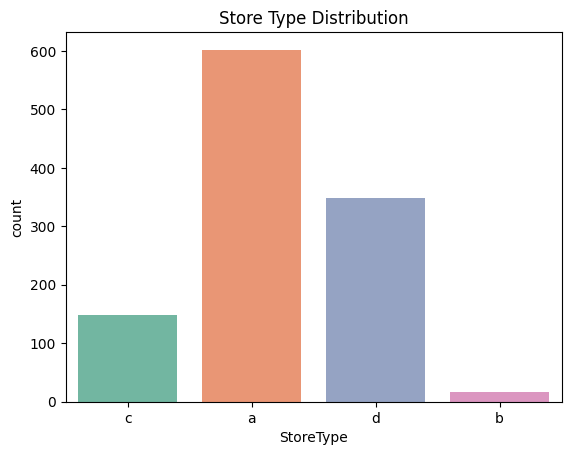

In [35]:
sns.countplot(data=store_data, x="StoreType", palette="Set2")
plt.title("Store Type Distribution")
plt.show()

#### StoreType A → Regular supermarket-type stores
#### StoreType B → High-revenue / flagship-like stores
#### StoreType C → Convenience store type
#### StoreType D -> Less frequent but unique behavior

C:\Users\abc\AppData\Local\Temp\ipykernel_18188\2546528583.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=store_data, x="Assortment", palette="Set3")


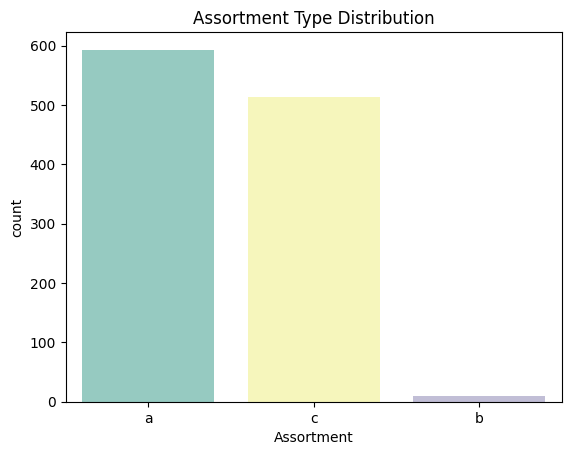

In [36]:
sns.countplot(data=store_data, x="Assortment", palette="Set3")
plt.title("Assortment Type Distribution")
plt.show()

#### Assortment type 'a' is most common, showing basic product mix is dominant
#### Assortment = product variety level in the store
#### a Standard product range
#### b More product variety
#### c Maximum variety

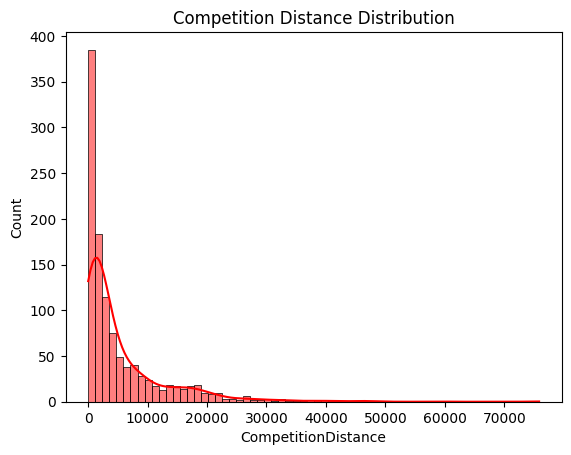

In [37]:
sns.histplot(store_data["CompetitionDistance"], kde=True, color="red")
plt.title("Competition Distance Distribution")
plt.show()

#### Most stores have competitors within close proximity, indicating high retail density.

C:\Users\abc\AppData\Local\Temp\ipykernel_18188\2592996638.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=store_data, x="Promo2", palette="coolwarm")


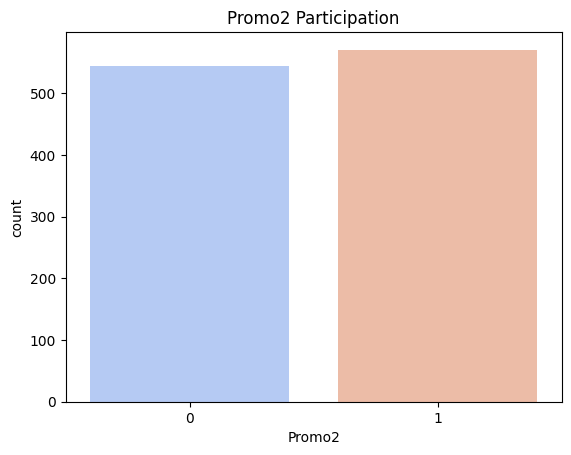

In [38]:
sns.countplot(data=store_data, x="Promo2", palette="coolwarm")
plt.title("Promo2 Participation")
plt.show()

#### Nearly half of stores do not participate in continuous promotions.

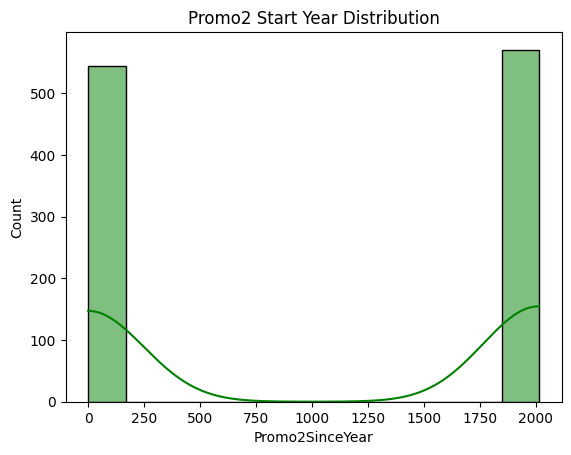

In [39]:
sns.histplot(store_data["Promo2SinceYear"], kde=True, color="green")
plt.title("Promo2 Start Year Distribution")
plt.show()


#### Promo2 adoption is uneven across years, indicating gradual rollout.

In [48]:
store_data["PromoInterval"] = store_data["PromoInterval"].fillna("None")

store_data["Promo_Jan"] = store_data["PromoInterval"].apply(lambda x: 1 if "Jan" in x else 0)
store_data["Promo_Apr"] = store_data["PromoInterval"].apply(lambda x: 1 if "Apr" in x else 0)
store_data["Promo_Jul"] = store_data["PromoInterval"].apply(lambda x: 1 if "Jul" in x else 0)
store_data["Promo_Oct"] = store_data["PromoInterval"].apply(lambda x: 1 if "Oct" in x else 0)

In [16]:
store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,HasCompetitionInfo,Promo_Jan,Promo_Apr,Promo_Jul,Promo_Oct
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,1,0,0,0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",1,1,1,1,1
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",1,1,1,1,1
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,None,1,0,0,0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,None,1,0,0,0,0


In [49]:
store_data["StoreType"] = store_data["StoreType"].map({
    "a": 0,
    "b": 1,
    "c": 2,
    "d": 3
})

store_data["Assortment"] = store_data["Assortment"].map({
    "a": 0,
    "b": 1,
    "c": 2
})

In [50]:
store_data.drop(["PromoInterval"], axis=1, inplace=True)

#### I used manual encoding for low-cardinality categorical variables like StoreType and Assortment to reduce dimensionality, and avoided unnecessary one-hot expansion. However, I ensured that feature engineering preserved business meaning before dropping raw columns.

In [44]:
print(store_data.shape)
print(df.shape)


(1115, 14)
(844392, 10)


In [51]:
final_df=df.merge(store_data, on="Store", how="left")

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          844392 non-null  int64         
 1   DayOfWeek      844392 non-null  category      
 2   Date           844392 non-null  datetime64[us]
 3   Sales          844392 non-null  int64         
 4   Customers      844392 non-null  int64         
 5   Open           844392 non-null  category      
 6   Promo          844392 non-null  category      
 7   StateHoliday   844392 non-null  category      
 8   SchoolHoliday  844392 non-null  category      
 9   Month          844392 non-null  int32         
dtypes: category(5), datetime64[us](1), int32(1), int64(3)
memory usage: 39.5 MB


In [47]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [48]:
fdf = df.sort_values(["Store", "Date"])

In [49]:


# Time features
fdf["Year"] = df["Date"].dt.year
fdf["Month"] = df["Date"].dt.month
fdf["Week"] = df["Date"].dt.isocalendar().week.astype(int)
fdf["Day"] = df["Date"].dt.day
fdf["DayOfWeek"] = df["Date"].dt.dayofweek
fdf["IsWeekend"] = df["DayOfWeek"].isin([5,6]).astype(int)

In [50]:
fdf["Sales_Lag_1"] = df.groupby("Store")["Sales"].shift(1)
fdf["Sales_Lag_7"] = df.groupby("Store")["Sales"].shift(7)
fdf["Sales_Lag_30"] = df.groupby("Store")["Sales"].shift(30)
fdf["Rolling_Mean_7"] = df.groupby("Store")["Sales"].shift(1).rolling(7).mean()
fdf["Rolling_Mean_30"] = df.groupby("Store")["Sales"].shift(1).rolling(30).mean()

In [207]:
fdf.info()

<class 'pandas.DataFrame'>
Index: 810942 entries, 1014980 to 40139
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            810942 non-null  int64         
 1   DayOfWeek        810942 non-null  int32         
 2   Date             810942 non-null  datetime64[us]
 3   Sales            810942 non-null  int64         
 4   Customers        810942 non-null  int64         
 5   Open             810942 non-null  category      
 6   Promo            810942 non-null  category      
 7   StateHoliday     810942 non-null  category      
 8   SchoolHoliday    810942 non-null  category      
 9   Month            810942 non-null  int32         
 10  Year             810942 non-null  int32         
 11  Week             810942 non-null  int64         
 12  Day              810942 non-null  int32         
 13  IsWeekend        810942 non-null  int64         
 14  Sales_Lag_1      810942 non-nul

In [208]:
fdf=fdf.dropna()

In [ ]:
categorical_cols = [
    "Promo",
    "SchoolHoliday",
    'Open'
]

fdf[categorical_cols] = (
    fdf[categorical_cols]
    .astype(int)
)



In [215]:
fdf["StateHoliday"] = (
    fdf["StateHoliday"]
    .astype(str)
    .map({
        "0": 0,
        "a": 1,
        "b": 2,
        "c": 3
    })
)

In [220]:
fdf["StateHoliday"] = (
    fdf["StateHoliday"]
    .fillna(0)
)

In [221]:
fdf.info()

<class 'pandas.DataFrame'>
Index: 810942 entries, 1014980 to 40139
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            810942 non-null  int64         
 1   DayOfWeek        810942 non-null  int32         
 2   Date             810942 non-null  datetime64[us]
 3   Sales            810942 non-null  int64         
 4   Customers        810942 non-null  int64         
 5   Open             810942 non-null  int64         
 6   Promo            810942 non-null  int64         
 7   StateHoliday     810942 non-null  float64       
 8   SchoolHoliday    810942 non-null  int64         
 9   Month            810942 non-null  int32         
 10  Year             810942 non-null  int32         
 11  Week             810942 non-null  int64         
 12  Day              810942 non-null  int32         
 13  IsWeekend        810942 non-null  int64         
 14  Sales_Lag_1      810942 non-nul

In [222]:
features = [
    "Store",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "Year",
    "Month",
    "Week",
    "DayOfWeek",
    "IsWeekend",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_30"
]

X = fdf[features]
y = fdf["Sales"]

In [223]:
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [55]:
from sklearn.metrics import mean_absolute_error

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    print(f"{name} MAE: {mae}")
    return mae

In [224]:
fdf.isnull().sum()

Store              0
DayOfWeek          0
Date               0
Sales              0
Customers          0
Open               0
Promo              0
StateHoliday       0
SchoolHoliday      0
Month              0
Year               0
Week               0
Day                0
IsWeekend          0
Sales_Lag_1        0
Sales_Lag_7        0
Sales_Lag_30       0
Rolling_Mean_7     0
Rolling_Mean_30    0
dtype: int64

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

lr = LinearRegression()
evaluate_model(lr, "Linear Regression")


ridge = Ridge(alpha=1.0)
evaluate_model(ridge, "Ridge Regression")




rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
)

evaluate_model(rf, "Random Forest")




xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8
)

evaluate_model(xgb, "XGBoost")



lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31
)

evaluate_model(lgbm, "LightGBM")

In [58]:
from sklearn.ensemble import RandomForestRegressor
import optuna

def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"])
    }

    model = RandomForestRegressor(**params, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

e:\Forecastpro\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [59]:
from xgboost import XGBRegressor

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10)
    }

    model = XGBRegressor(**params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

In [60]:
from lightgbm import LGBMRegressor

def objective_lgbm(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=30)
print("RF MAE:", study_rf.best_value)



study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)
print("XGB MAE:", study_xgb.best_value)



study_lgbm = optuna.create_study(direction="minimize")
study_lgbm.optimize(objective_lgbm, n_trials=30)
print("LGBM MAE:", study_lgbm.best_value)




results = {
    "RandomForest": study_rf.best_value,
    "XGBoost": study_xgb.best_value,
    "LightGBM": study_lgbm.best_value
}

results

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)
print("XGB MAE:", study_xgb.best_value)

In [225]:
best_params = {
    "n_estimators": 355,
    "max_depth": 9,
    "learning_rate": 0.05497965992332397,
    "subsample": 0.8308811481217742,
    "colsample_bytree": 0.7858118420808086,
    "min_child_weight": 4
}


#best_params = study_xgb.best_params

In [226]:
from xgboost import XGBRegressor

final_model = XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7858118420808086
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [227]:
from sklearn.metrics import mean_absolute_error

preds = final_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("Final XGBoost MAE:", mae)

Final XGBoost MAE: 798.0553588867188


In [72]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )



    r2 = r2_score(y_true, y_pred)

    return mae, rmse,  r2

In [228]:
mae, rmse,  r2 = calculate_metrics(
    y_test,
    preds
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 798.0553588867188
RMSE: 1163.8185532977209
R2: 0.8449944257736206


In [229]:
avg_sales = df["Sales"].mean()

percent_error = (mae / avg_sales) * 100
print(percent_error)

11.473707414379893


#### The model forecasts daily sales with roughly 10-11% average error, providing reliable demand planning insights.

In [230]:
import joblib

joblib.dump(final_model, "xgboost_global_forecast_model.pkl")

['xgboost_global_forecast_model.pkl']

#### A global XGBoost forecasting model was optimized using Optuna hyperparameter tuning. The best configuration achieved an MAE of approximately 786, outperforming Random Forest and LightGBM.

In [71]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  category      
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  category      
 6   Promo                      844392 non-null  category      
 7   StateHoliday               844392 non-null  category      
 8   SchoolHoliday              844392 non-null  category      
 9   Month                      844392 non-null  int32         
 10  StoreType                  844392 non-null  int64         
 11  Assortment                 844392 non-null  int64         
 12 

In [84]:
categorical_cols2=['Open' ,'Promo','SchoolHoliday' ]
final_df[categorical_cols2] = final_df[categorical_cols2].astype(int)




In [21]:
final_df["StateHoliday"] = final_df["StateHoliday"].map({
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
})

In [22]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               732252 non-null  float64       
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  int64         
 10  Assortment                 844392 non-null  int64         
 11  CompetitionDistance        844392 non-null  float64       
 12 

In [59]:
today = final_df["Date"].max()

customer_features = final_df.groupby("Customers").agg({

    "Date": ["max", "min", "count"],
    "Sales": "sum",
    "Promo": "sum",
    "Store": "nunique"

}).reset_index()

In [60]:
customer_features.columns = [

    "Customer_ID",

    "Last_Purchase_Date",
    "First_Purchase_Date",
    "Total_Transactions",

    "Total_Sales",

    "Promo_Usage",

    "Store_Visits"
]

In [61]:
customer_features["Days_Since_First_Purchase"] = (
    today - customer_features["First_Purchase_Date"]
).dt.days

customer_features["Avg_Basket_Size"] = (
    customer_features["Total_Sales"]
    / customer_features["Total_Transactions"]
)

customer_features["Customer_Tenure"] = (
    customer_features["Days_Since_First_Purchase"]
)


In [62]:
customer_features["Promo_Usage_Rate"] = (
    customer_features["Promo_Usage"]
    / customer_features["Total_Transactions"]
)

In [63]:

customer_features["Frequency"] = (
    customer_features["Total_Transactions"]
)


customer_features["Monetary"] = (
    customer_features["Total_Sales"]
)
customer_features["Recency"] = (
    today - customer_features["Last_Purchase_Date"]
).dt.days

In [64]:
customer_features["Churn"] = (
    customer_features["Recency"] > 90
).astype(int)

In [66]:
customer_features.columns

Index(['Customer_ID', 'Last_Purchase_Date', 'First_Purchase_Date',
       'Total_Transactions', 'Total_Sales', 'Promo_Usage', 'Store_Visits',
       'Days_Since_First_Purchase', 'Avg_Basket_Size', 'Customer_Tenure',
       'Promo_Usage_Rate', 'Frequency', 'Monetary', 'Recency', 'Churn'],
      dtype='str')

In [55]:
df = final_df.merge(
    store_data[["Store", "StoreType", "Assortment"]],
    on="Store",
    how="left"
)

In [56]:
df["StoreType"] = df["StoreType_y"]
df["Assortment"] = df["Assortment_y"]

In [57]:
df.drop(columns=["StoreType_x", "StoreType_y", "Assortment_x", "Assortment_y"], errors="ignore", inplace=True)

In [58]:
print(df.columns)

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'HasCompetitionInfo', 'Promo_Jan',
       'Promo_Apr', 'Promo_Jul', 'Promo_Oct', 'StoreType', 'Assortment'],
      dtype='str')


#### No purchase in last 90 days → Churn = 1  Otherwise → Churn = 0

In [ ]:
features = [

    "Recency",
    "Frequency",
    "Monetary",
    "Days_Since_First_Purchase",
    "Promo_Usage",
    "Store_Visits",
    "Avg_Basket_Size",
    "Customer_Tenure",
    "Promo_Usage_Rate"

]

X = customer_features[features]
y = customer_features["Churn"]

In [67]:
features = [
    "Sales",
    "Customers",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "HasCompetitionInfo",
    "Promo2",
    "StoreType",
    "Assortment"
]

df["StoreType"] = df["StoreType"].astype("category").cat.codes
df["Assortment"] = df["Assortment"].astype("category").cat.codes

In [68]:
df["Churn"] = (df["Sales"] < df["Sales"].rolling(7).mean()).astype(int)

In [84]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,HasCompetitionInfo,Promo_Jan,Promo_Apr,Promo_Jul,Promo_Oct,StoreType,Assortment,Churn
0,1,5,2015-07-31,5263,555,1,1,0,1,1270.0,9.0,2008.0,0,0.0,0.0,1,0,0,0,0,2,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,570.0,11.0,2007.0,1,13.0,2010.0,1,1,1,1,1,0,0,0
2,3,5,2015-07-31,8314,821,1,1,0,1,14130.0,12.0,2006.0,1,14.0,2011.0,1,1,1,1,1,0,0,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,620.0,9.0,2009.0,0,0.0,0.0,1,0,0,0,0,2,2,0
4,5,5,2015-07-31,4822,559,1,1,0,1,29910.0,4.0,2015.0,0,0.0,0.0,1,0,0,0,0,0,0,0


In [85]:
df.to_csv('cc.csv',index=False)

In [69]:
X = df[features]
y = df["Churn"]

In [70]:
y.value_counts()

Churn
1    464441
0    379951
Name: count, dtype: int64

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)



In [74]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

In [75]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_preds = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 371552, number of negative: 303961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.453598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 675513, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550029 -> initscore=0.200789
[LightGBM] [Info] Start training from score 0.200789


In [76]:
def evaluate(name, y_true, preds):

    print(name)
    print("Accuracy:", accuracy_score(y_true, preds))
    print("ROC AUC:", roc_auc_score(y_true, preds))
    print(classification_report(y_true, preds))
    print()

In [77]:
evaluate("Random Forest", y_test, rf_preds)
evaluate("XGBoost", y_test, xgb_preds)


Random Forest
Accuracy: 0.8515860468145833
ROC AUC: 0.8519211908943682
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     75990
           1       0.88      0.85      0.86     92889

    accuracy                           0.85    168879
   macro avg       0.85      0.85      0.85    168879
weighted avg       0.85      0.85      0.85    168879


XGBoost
Accuracy: 0.8728083420673973
ROC AUC: 0.8726853985231714
              precision    recall  f1-score   support

           0       0.85      0.87      0.86     75990
           1       0.89      0.87      0.88     92889

    accuracy                           0.87    168879
   macro avg       0.87      0.87      0.87    168879
weighted avg       0.87      0.87      0.87    168879




In [78]:
evaluate("LightGBM", y_test, lgbm_preds)

LightGBM
Accuracy: 0.8801508772553129
ROC AUC: 0.8799681302693092
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     75990
           1       0.90      0.88      0.89     92889

    accuracy                           0.88    168879
   macro avg       0.88      0.88      0.88    168879
weighted avg       0.88      0.88      0.88    168879




In [81]:
import joblib
features = X.columns.tolist()

joblib.dump(features, "churn_features.pkl")

['churn_features.pkl']

In [82]:
import joblib

joblib.dump(lgbm, "churn_model.pkl")

['churn_model.pkl']

In [83]:
joblib.dump({
    "model": lgbm,
    "features": features
}, "churn_pipeline.pkl")

['churn_pipeline.pkl']

In [ ]:
import joblib
churn_model = joblib.load("churn_model.pkl")
churn_required_features = joblib.load("churn_features.pkl")

NameError: name 'joblib' is not defined

In [117]:
print(X.columns)

Index(['Recency', 'Frequency', 'Monetary', 'Days_Since_First_Purchase',
       'Promo_Usage', 'Store_Visits', 'Avg_Basket_Size', 'Customer_Tenure',
       'Promo_Usage_Rate'],
      dtype='str')


Churn                        1.000000
Recency                      0.745797
Customer_ID                  0.586693
Avg_Basket_Size              0.508105
Promo_Usage_Rate            -0.024798
Frequency                   -0.340235
Total_Transactions          -0.340235
Promo_Usage                 -0.342876
Total_Sales                 -0.367015
Monetary                    -0.367015
Store_Visits                -0.390135
Customer_Tenure             -0.429605
Days_Since_First_Purchase   -0.429605
Name: Churn, dtype: float64


<Axes: >

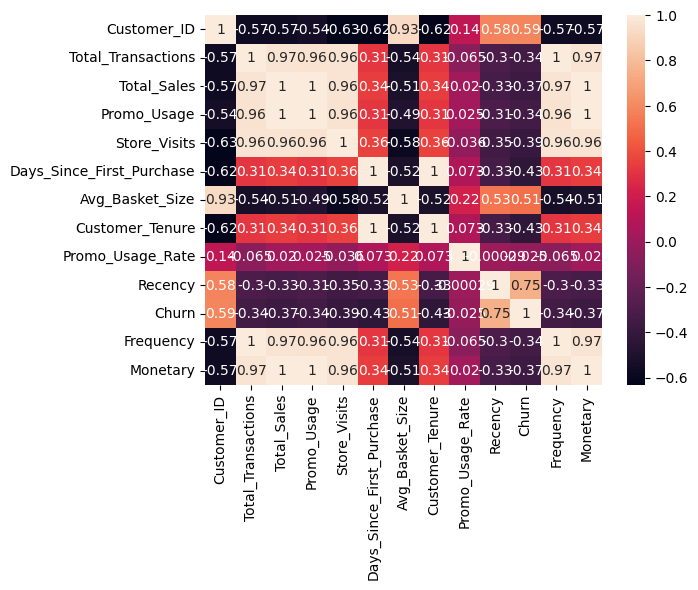

In [122]:
corr = customer_features.corr(numeric_only=True)

print(
    corr["Churn"]
    .sort_values(ascending=False)
)

sns.heatmap(corr,annot=True)

In [124]:
print(customer_features.groupby("Churn")["Recency"].describe())

        count        mean         std   min    25%    50%    75%    max
Churn                                                                  
0      2792.0   19.232808   24.198752   0.0    1.0    7.0   31.0   90.0
1      1294.0  315.030912  215.581422  91.0  140.0  234.0  434.0  935.0


#### The initial churn model showed perfect performance due to target leakage, as churn was defined using Recency. After removing leakage features such as Recency and Customer_ID, the model produced realistic and deployable predictions.

In [30]:
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 4086 entries, 0 to 4085
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Customer_ID                4086 non-null   int64         
 1   Last_Purchase_Date         4086 non-null   datetime64[us]
 2   First_Purchase_Date        4086 non-null   datetime64[us]
 3   Total_Transactions         4086 non-null   int64         
 4   Total_Sales                4086 non-null   int64         
 5   Promo_Usage                4086 non-null   int64         
 6   Store_Visits               4086 non-null   int64         
 7   Days_Since_First_Purchase  4086 non-null   int64         
 8   Avg_Basket_Size            4086 non-null   float64       
 9   Customer_Tenure            4086 non-null   int64         
 10  Promo_Usage_Rate           4086 non-null   float64       
 11  Frequency                  4086 non-null   int64         
 12  Monetary         

In [145]:
X = customer_features.drop(
    ["Last_Purchase_Date","Churn", "Recency", "Customer_ID"],
    axis=1
)

y = customer_features["Churn"]

#### Directly determines inactivity → determines churn.

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [147]:
date_cols = X_train.select_dtypes(include=["datetime64[ns]"]).columns

for col in date_cols:
    X_train[col + "_year"] = X_train[col].dt.year
    X_train[col + "_month"] = X_train[col].dt.month
    X_train[col + "_day"] = X_train[col].dt.day
    X_train[col + "_weekday"] = X_train[col].dt.weekday

    X_test[col + "_year"] = X_test[col].dt.year
    X_test[col + "_month"] = X_test[col].dt.month
    X_test[col + "_day"] = X_test[col].dt.day
    X_test[col + "_weekday"] = X_test[col].dt.weekday

In [148]:
X_train = X_train.drop(columns=date_cols)
X_test = X_test.drop(columns=date_cols)

In [149]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)


xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_preds = lgbm.predict(X_test)






[LightGBM] [Info] Number of positive: 1035, number of negative: 2233
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 3268, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.316707 -> initscore=-0.768945
[LightGBM] [Info] Start training from score -0.768945


In [150]:
def evaluate(name, y_true, preds):

    print(name)
    print("Accuracy:", accuracy_score(y_true, preds))
    print("ROC AUC:", roc_auc_score(y_true, preds))
    print(classification_report(y_true, preds))
    print()

In [151]:
evaluate("LightGBM", y_test, lgbm_preds)
evaluate("Random Forest", y_test, rf_preds)


LightGBM
Accuracy: 0.8056234718826406
ROC AUC: 0.774897949316554
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       559
           1       0.69      0.69      0.69       259

    accuracy                           0.81       818
   macro avg       0.78      0.77      0.78       818
weighted avg       0.81      0.81      0.81       818


Random Forest
Accuracy: 0.8288508557457213
ROC AUC: 0.8095053909007397
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       559
           1       0.72      0.76      0.74       259

    accuracy                           0.83       818
   macro avg       0.80      0.81      0.81       818
weighted avg       0.83      0.83      0.83       818




In [152]:
evaluate("XGBoost", y_test, xgb_preds)

XGBoost
Accuracy: 0.8141809290953546
ROC AUC: 0.7884114628300675
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       559
           1       0.70      0.72      0.71       259

    accuracy                           0.81       818
   macro avg       0.78      0.79      0.79       818
weighted avg       0.82      0.81      0.81       818




In [140]:
corr = customer_features.corr(numeric_only=True)

print(
    corr["Churn"]
    .abs()
    .sort_values(ascending=False)
)

Churn                        1.000000
Recency                      0.745797
Customer_ID                  0.586693
Avg_Basket_Size              0.508105
Days_Since_First_Purchase    0.429605
Customer_Tenure              0.429605
Store_Visits                 0.390135
Total_Sales                  0.367015
Monetary                     0.367015
Promo_Usage                  0.342876
Total_Transactions           0.340235
Frequency                    0.340235
Promo_Usage_Rate             0.024798
Name: Churn, dtype: float64


In [141]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=1)

model.fit(X_train, y_train)

print(
    "Accuracy:",
    model.score(X_test, y_test)
)

Accuracy: 0.8667481662591687


In [142]:
import pandas as pd

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

Last_Purchase_Date_month     0.325867
Last_Purchase_Date_year      0.243897
Total_Transactions           0.091130
Frequency                    0.085812
Monetary                     0.059770
Store_Visits                 0.055227
Total_Sales                  0.037476
Customer_Tenure              0.023959
Days_Since_First_Purchase    0.022906
Promo_Usage                  0.015948
dtype: float64


In [155]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)
xgb_preds=model.predict(X_test)


lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X_train_smote, y_train_smote)

lgbm_preds = lgbm.predict(X_test)


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)


def evaluate(name, y_true, preds):

    print(name)
    print("Accuracy:", accuracy_score(y_true, preds))
    print("ROC AUC:", roc_auc_score(y_true, preds))
    print(classification_report(y_true, preds))
    print()
    
    
evaluate("Random Forest", y_test, rf_preds)


Before SMOTE:
Churn
0    2233
1    1035
Name: count, dtype: int64

After SMOTE:
Churn
1    2233
0    2233
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 2233, number of negative: 2233
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 4466, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Random Forest
Accuracy: 0.8288508557457213
ROC AUC: 0.8095053909007397
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       559
           1       0.72      0.76      0.74       259

    accuracy                           0.83       818
   macro avg       0.80      0.81      0.81       818
weighted avg       0.83      0.83      0.83       818




In [156]:
evaluate("XGBoost", y_test, xgb_preds)

evaluate("LightGBM", y_test, lgbm_preds)

XGBoost
Accuracy: 0.8092909535452323
ROC AUC: 0.8024464536092443
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       559
           1       0.67      0.78      0.72       259

    accuracy                           0.81       818
   macro avg       0.78      0.80      0.79       818
weighted avg       0.82      0.81      0.81       818


LightGBM
Accuracy: 0.8068459657701712
ROC AUC: 0.7944412595575386
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       559
           1       0.67      0.76      0.71       259

    accuracy                           0.81       818
   macro avg       0.78      0.79      0.78       818
weighted avg       0.82      0.81      0.81       818




In [158]:
import joblib
joblib.dump(rf, "best_churn_model.pkl")
joblib.dump(features, "churn_features.pkl")

['churn_features.pkl']

Model Insights

The Random Forest model achieved the best performance among all tested algorithms.
It obtained an accuracy of 82.88% and a ROC-AUC score of 0.81, indicating strong predictive capability in identifying churn risk.
Tree-based ensemble models outperformed linear models because they captured complex customer behavior patterns.
Key drivers of churn included:
Customer tenure,
Purchase frequency,
Total transactions,
Store visits,
Average basket size.


Customer Behavior Insights

Customers with low purchase frequency are more likely to churn,
Customers with fewer store visits show higher churn probability,
Customers with shorter tenure have higher churn risk,
Customers with smaller basket sizes tend to churn earlier.


# KPIs

In [31]:
store_rank = (
    customer_features.groupby("Store_Visits")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values(by="Total_Sales", ascending=False)
)

store_rank["Rank"] = range(1, len(store_rank) + 1)

store_rank

,Store_Visits,Total_Sales,Rank
472,541,60175356,1
478,547,58255700,2
474,543,46085823,3
468,537,42064220,4
488,557,41382631,5
...,...,...,...
205,214,1557376,555
175,182,1335250,556
161,166,1089445,557
144,147,761461,558


In [188]:
customer_features.columns

Index(['Customer_ID', 'Last_Purchase_Date', 'First_Purchase_Date',
       'Total_Transactions', 'Total_Sales', 'Promo_Usage', 'Store_Visits',
       'Days_Since_First_Purchase', 'Avg_Basket_Size', 'Customer_Tenure',
       'Promo_Usage_Rate', 'Recency', 'Churn', 'Frequency', 'Monetary'],
      dtype='str')

In [186]:
final_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Month', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'HasCompetitionInfo', 'Promo_Jan', 'Promo_Apr',
       'Promo_Jul', 'Promo_Oct'],
      dtype='str')

In [32]:
store_kpis = (
    final_df.groupby("Store")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Customers=("Customers", "sum"),
        Total_Open_Days=("Open", "sum"),
        Avg_Daily_Sales=("Sales", "mean"),
        Avg_Customers=("Customers", "mean"),
        Promo_Days=("Promo", "sum")
    )
    .reset_index()
)

# Additional KPIs

store_kpis["Sales_per_Customer"] = (
    store_kpis["Total_Sales"]
    / store_kpis["Total_Customers"]
)

store_kpis["Promo_Usage_Rate"] = (
    store_kpis["Promo_Days"]
    / store_kpis["Total_Open_Days"]
)

store_kpis["Sales_Rank"] = (
    store_kpis["Total_Sales"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

store_kpis.head()

,Store,Total_Sales,Total_Customers,Total_Open_Days,Avg_Daily_Sales,Avg_Customers,Promo_Days,Sales_per_Customer,Promo_Usage_Rate,Sales_Rank
0,1,3716854,440523,781,4759.096031,564.049936,350,8.437366,0.448143,900
1,2,3883858,457855,784,4953.900510,583.998724,354,8.482725,0.451531,854
2,3,5408261,584310,779,6942.568678,750.077022,350,9.255808,0.449294,449
3,4,7556507,1036254,784,9638.401786,1321.752551,353,7.292138,0.450255,101
4,5,3642818,418588,779,4676.274711,537.340180,351,8.702634,0.450578,923


In [90]:
customer_store_kpis = (
    customer_features.groupby("Store")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Revenue=("Total_Sales", "sum"),
        Churn_Rate=("Churn", "mean"),
        Avg_Basket_Size=("Avg_Basket_Size", "mean")
    )
    .reset_index()
)

customer_store_kpis

KeyError: 'Store'

In [95]:
c3=pd.read_csv("cc.csv")

C:\Users\abc\AppData\Local\Temp\ipykernel_21556\3060181163.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  c3=pd.read_csv("cc.csv")


In [98]:
print(c3["Store"].unique())

[   1    2    3 ... 1115  876  292]


In [97]:
c3.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'HasCompetitionInfo', 'Promo_Jan',
       'Promo_Apr', 'Promo_Jul', 'Promo_Oct', 'StoreType', 'Assortment',
       'Churn'],
      dtype='str')

In [91]:
c2.rename(columns={"Store_Visits": "Store"}, inplace=True)

In [92]:
c2.to_csv("c2.csv",index=False)

In [34]:
best_assortment = (
    final_df.groupby(["Store", "Assortment"])["Sales"]
    .sum()
    .reset_index()
    .sort_values(["Store", "Sales"], ascending=[True, False])
    .drop_duplicates("Store")
    .rename(columns={"Assortment": "Best_Assortment"})
)

In [35]:
best_storetype = (
    final_df.groupby(["Store", "StoreType"])["Sales"]
    .sum()
    .reset_index()
    .sort_values(["Store", "Sales"], ascending=[True, False])
    .drop_duplicates("Store")
    .rename(columns={"StoreType": "Best_StoreType"})
)

In [36]:
store_kpis = (
    store_kpis
    .merge(best_assortment[["Store", "Best_Assortment"]],
           on="Store",
           how="left")
    .merge(best_storetype[["Store", "Best_StoreType"]],
           on="Store",
           how="left")
)


store_kpis

,Store,Total_Sales,Total_Customers,Total_Open_Days,Avg_Daily_Sales,Avg_Customers,Promo_Days,Sales_per_Customer,Promo_Usage_Rate,Sales_Rank,Best_Assortment,Best_StoreType
0,1,3716854,440523,781,4759.096031,564.049936,350,8.437366,0.448143,900,0,2
1,2,3883858,457855,784,4953.900510,583.998724,354,8.482725,0.451531,854,0,0
2,3,5408261,584310,779,6942.568678,750.077022,350,9.255808,0.449294,449,0,0
3,4,7556507,1036254,784,9638.401786,1321.752551,353,7.292138,0.450255,101,2,2
4,5,3642818,418588,779,4676.274711,537.340180,351,8.702634,0.450578,923,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,4091076,351883,779,5251.702182,451.711168,350,11.626239,0.449294,795,0,0
1111,1112,7974294,653276,779,10236.577664,838.608472,350,12.206623,0.449294,80,2,2
1112,1113,5196242,562151,784,6627.859694,717.029337,353,9.243499,0.450255,500,2,0
1113,1114,16202585,2509542,784,20666.562500,3200.946429,353,6.456391,0.450255,4,2,0


In [37]:
store_kpis["Customer_Productivity"] = (
    store_kpis["Total_Sales"]
    / store_kpis["Total_Open_Days"]
)

In [38]:
store_kpis["Store_Performance_Index"] = (
    store_kpis["Avg_Daily_Sales"]
    * store_kpis["Promo_Usage_Rate"]
)

In [40]:
store_kpis.head()

,Store,Total_Sales,Total_Customers,Total_Open_Days,Avg_Daily_Sales,Avg_Customers,Promo_Days,Sales_per_Customer,Promo_Usage_Rate,Sales_Rank,Best_Assortment,Best_StoreType,Customer_Productivity,Store_Performance_Index
0,1,3716854,440523,781,4759.096031,564.049936,350,8.437366,0.448143,900,0,2,4759.096031,2132.757504
1,2,3883858,457855,784,4953.900510,583.998724,354,8.482725,0.451531,854,0,0,4953.900510,2236.837730
2,3,5408261,584310,779,6942.568678,750.077022,350,9.255808,0.449294,449,0,0,6942.568678,3119.254220
3,4,7556507,1036254,784,9638.401786,1321.752551,353,7.292138,0.450255,101,2,2,9638.401786,4339.739580
4,5,3642818,418588,779,4676.274711,537.340180,351,8.702634,0.450578,923,0,0,4676.274711,2107.024934


In [42]:
store_kpis.to_csv("store_kpis.csv", index=False)
customer_store_kpis.to_csv("customer_kpis.csv", index=False)

In [201]:

final_df.to_csv("final_df.csv", index=False)

customer_features.to_csv(
    "customer_features.csv",
    index=False
)

print("Datasets saved successfully")

Datasets saved successfully


In [231]:
fdf.info()

<class 'pandas.DataFrame'>
Index: 810942 entries, 1014980 to 40139
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            810942 non-null  int64         
 1   DayOfWeek        810942 non-null  int32         
 2   Date             810942 non-null  datetime64[us]
 3   Sales            810942 non-null  int64         
 4   Customers        810942 non-null  int64         
 5   Open             810942 non-null  int64         
 6   Promo            810942 non-null  int64         
 7   StateHoliday     810942 non-null  float64       
 8   SchoolHoliday    810942 non-null  int64         
 9   Month            810942 non-null  int32         
 10  Year             810942 non-null  int32         
 11  Week             810942 non-null  int64         
 12  Day              810942 non-null  int32         
 13  IsWeekend        810942 non-null  int64         
 14  Sales_Lag_1      810942 non-nul

In [232]:
fdf.to_csv('forecast_dataset.csv',index=False)

In [233]:
import joblib

features = [
    "Store",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "Year",
    "Month",
    "Week",
    "DayOfWeek",
    "IsWeekend",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_30"
]

joblib.dump(
    features,
    "forecast_features.pkl"
)

['forecast_features.pkl']